# Inspect FRED Macro Dataset

This notebook inspects the private Hugging Face dataset
`cookekieran/fred-macro-data` without modifying it. It shows:

- every file and table stored in the repository;
- every collected macroeconomic variable, FRED ID, description, and frequency;
- representative and recent values for each variable;
- date coverage, missingness, duplicates, and where each series stops;
- an important warning about publication dates, revisions, and leakage.

`HF_TOKEN` is loaded from `.env`; no token is stored in this notebook.

In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from dotenv import load_dotenv
from huggingface_hub import HfApi, hf_hub_download

REPO_ID = "cookekieran/fred-macro-data"
REPO_TYPE = "dataset"

load_dotenv(Path.cwd() / ".env")
HF_TOKEN = os.getenv("HF_TOKEN")
assert HF_TOKEN, "HF_TOKEN is missing. Add it to the local .env file."

api = HfApi(token=HF_TOKEN)
repo_info = api.repo_info(repo_id=REPO_ID, repo_type=REPO_TYPE)
REVISION = repo_info.sha
print(f"Repository: {REPO_ID}")
print(f"Pinned revision: {REVISION}")

Repository: cookekieran/fred-macro-data
Pinned revision: 3b12b255a8eabbfbb84d6311169bd91b268ef5c8


## Repository contents

In [2]:
repo_files = api.list_repo_files(
    repo_id=REPO_ID, repo_type=REPO_TYPE, revision=REVISION
)
inventory = pd.DataFrame({"path": repo_files})
inventory["extension"] = inventory["path"].str.extract(r"(\.[^.]+)$", expand=False).fillna("")
display(inventory)
print(f"Repository contains {len(repo_files)} files.")

,path,extension
0,.gitattributes,.gitattributes
1,README.md,.md
2,fred_macro_raw.csv,.csv
3,fred_macro_raw.parquet,.parquet
4,fred_series.json,.json
5,macro_monthly.csv,.csv
6,macro_monthly.parquet,.parquet


Repository contains 7 files.


## Download and inspect every stored table

In [3]:
tables = {}
json_files = {}
for path_in_repo in repo_files:
    suffix = Path(path_in_repo).suffix.lower()
    if suffix not in {".parquet", ".csv", ".json"}:
        continue
    local_path = hf_hub_download(
        repo_id=REPO_ID,
        filename=path_in_repo,
        repo_type=REPO_TYPE,
        revision=REVISION,
        token=HF_TOKEN,
    )
    if suffix == ".json":
        with open(local_path, encoding="utf-8") as handle:
            json_files[path_in_repo] = json.load(handle)
        print(f"{path_in_repo}: JSON")
    else:
        frame = pd.read_parquet(local_path) if suffix == ".parquet" else pd.read_csv(local_path)
        tables[path_in_repo] = frame
        print(f"{path_in_repo}: {len(frame):,} rows x {len(frame.columns)} columns")
        print(frame.dtypes.to_string())
        display(frame.head(3))

fred_macro_raw.csv: 11,669 rows x 6 columns
date                 object
value               float64
feature              object
fred_id              object
description          object
native_frequency     object


,date,value,feature,fred_id,description,native_frequency
0,2022-01-01,282.543,cpi,CPIAUCSL,Consumer Price Index for All Urban Consumers,monthly
1,2022-02-01,284.500,cpi,CPIAUCSL,Consumer Price Index for All Urban Consumers,monthly
2,2022-03-01,287.674,cpi,CPIAUCSL,Consumer Price Index for All Urban Consumers,monthly


fred_macro_raw.parquet: 11,669 rows x 6 columns
date                datetime64[us]
value                      float64
feature                     object
fred_id                     object
description                 object
native_frequency            object


,date,value,feature,fred_id,description,native_frequency
0,2022-01-01,282.543,cpi,CPIAUCSL,Consumer Price Index for All Urban Consumers,monthly
1,2022-02-01,284.500,cpi,CPIAUCSL,Consumer Price Index for All Urban Consumers,monthly
2,2022-03-01,287.674,cpi,CPIAUCSL,Consumer Price Index for All Urban Consumers,monthly


fred_series.json: JSON
macro_monthly.csv: 41 rows x 40 columns
month_end                     object
baa_10y_credit_spread        float64
core_cpi                     float64
core_pce_price_index         float64
cpi                          float64
fed_funds_rate               float64
fed_target_lower             float64
fed_target_upper             float64
industrial_production        float64
nonfarm_payrolls             float64
pce_price_index              float64
real_gdp                     float64
trade_weighted_dollar        float64
treasury_10y                 float64
treasury_10y_2y_spread       float64
treasury_2y                  float64
unemployment_rate            float64
vix                          float64
wti_oil                      float64
month                         object
cpi_yoy                      float64
core_cpi_yoy                 float64
pce_yoy                      float64
core_pce_yoy                 float64
fed_funds_change_1m          float64
fed_funds_ch

,month_end,baa_10y_credit_spread,core_cpi,core_pce_price_index,cpi,fed_funds_rate,fed_target_lower,fed_target_upper,industrial_production,nonfarm_payrolls,...,industrial_production_yoy,real_gdp_yoy,high_inflation,very_high_inflation,rising_rates,falling_rates,inverted_yield_curve,tightening_regime,easing_regime,macro_regime
0,2023-01-31,1.90,302.642,117.505,300.420,4.33,4.25,4.50,100.5050,154776.0,...,0.318808,2.311146,1,1,1,0,1,1,0,tightening
1,2023-02-28,1.90,304.123,117.929,301.450,4.57,4.50,4.75,100.6416,155066.0,...,-0.163482,2.311146,1,1,1,0,1,1,0,tightening
2,2023-03-31,2.11,305.147,118.315,301.821,4.65,4.75,5.00,101.0205,155134.0,...,-0.365122,2.311146,1,0,1,0,1,1,0,tightening


macro_monthly.parquet: 41 rows x 40 columns
month_end                    datetime64[us]
baa_10y_credit_spread               float64
core_cpi                            float64
core_pce_price_index                float64
cpi                                 float64
fed_funds_rate                      float64
fed_target_lower                    float64
fed_target_upper                    float64
industrial_production               float64
nonfarm_payrolls                    float64
pce_price_index                     float64
real_gdp                            float64
trade_weighted_dollar               float64
treasury_10y                        float64
treasury_10y_2y_spread              float64
treasury_2y                         float64
unemployment_rate                   float64
vix                                 float64
wti_oil                             float64
month                                object
cpi_yoy                             float64
core_cpi_yoy                    

,month_end,baa_10y_credit_spread,core_cpi,core_pce_price_index,cpi,fed_funds_rate,fed_target_lower,fed_target_upper,industrial_production,nonfarm_payrolls,...,industrial_production_yoy,real_gdp_yoy,high_inflation,very_high_inflation,rising_rates,falling_rates,inverted_yield_curve,tightening_regime,easing_regime,macro_regime
0,2023-01-31,1.90,302.642,117.505,300.420,4.33,4.25,4.50,100.5050,154776.0,...,0.318808,2.311146,1,1,1,0,1,1,0,tightening
1,2023-02-28,1.90,304.123,117.929,301.450,4.57,4.50,4.75,100.6416,155066.0,...,-0.163482,2.311146,1,1,1,0,1,1,0,tightening
2,2023-03-31,2.11,305.147,118.315,301.821,4.65,4.75,5.00,101.0205,155134.0,...,-0.365122,2.311146,1,0,1,0,1,1,0,tightening


## Identify the canonical raw FRED observations

The canonical table should be long-form, with one observation per `feature` and
`date`. Other stored tables are also displayed above, but the remaining audit
uses this raw table.

In [4]:
raw_candidates = {
    name: frame for name, frame in tables.items()
    if {"date", "value", "feature"}.issubset(frame.columns)
}
assert raw_candidates, "No long-form table with date, value, and feature was found."
raw_name, raw = max(raw_candidates.items(), key=lambda item: len(item[1]))
raw = raw.copy()
raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
raw["value"] = pd.to_numeric(raw["value"], errors="coerce")
raw = raw.sort_values(["feature", "date"]).reset_index(drop=True)
print(f"Canonical raw table: {raw_name}")
print(f"Rows: {len(raw):,}")
display(raw.head(10))

Canonical raw table: fred_macro_raw.csv
Rows: 11,669


,date,value,feature,fred_id,description,native_frequency
0,2022-01-03,1.82,baa_10y_credit_spread,BAA10Y,Moody's BAA corporate bond yield minus 10-year...,daily
1,2022-01-04,1.84,baa_10y_credit_spread,BAA10Y,Moody's BAA corporate bond yield minus 10-year...,daily
2,2022-01-05,1.80,baa_10y_credit_spread,BAA10Y,Moody's BAA corporate bond yield minus 10-year...,daily
3,2022-01-06,1.78,baa_10y_credit_spread,BAA10Y,Moody's BAA corporate bond yield minus 10-year...,daily
4,2022-01-07,1.78,baa_10y_credit_spread,BAA10Y,Moody's BAA corporate bond yield minus 10-year...,daily
5,2022-01-10,1.76,baa_10y_credit_spread,BAA10Y,Moody's BAA corporate bond yield minus 10-year...,daily
6,2022-01-11,1.76,baa_10y_credit_spread,BAA10Y,Moody's BAA corporate bond yield minus 10-year...,daily
7,2022-01-12,1.77,baa_10y_credit_spread,BAA10Y,Moody's BAA corporate bond yield minus 10-year...,daily
8,2022-01-13,1.80,baa_10y_credit_spread,BAA10Y,Moody's BAA corporate bond yield minus 10-year...,daily
9,2022-01-14,1.79,baa_10y_credit_spread,BAA10Y,Moody's BAA corporate bond yield minus 10-year...,daily


## Complete variable catalogue

In [5]:
catalogue_fields = [
    column for column in ["feature", "fred_id", "description", "native_frequency"]
    if column in raw.columns
]
variable_catalogue = (
    raw[catalogue_fields].drop_duplicates().sort_values("feature").reset_index(drop=True)
)
display(variable_catalogue)
print(f"Collected variables: {raw['feature'].nunique()}")

,feature,fred_id,description,native_frequency
0,baa_10y_credit_spread,BAA10Y,Moody's BAA corporate bond yield minus 10-year...,daily
1,core_cpi,CPILFESL,Core Consumer Price Index excluding food and e...,monthly
2,core_pce_price_index,PCEPILFE,Core PCE price index excluding food and energy,monthly
3,cpi,CPIAUCSL,Consumer Price Index for All Urban Consumers,monthly
4,fed_funds_rate,FEDFUNDS,Effective federal funds rate,monthly
5,fed_target_lower,DFEDTARL,Federal funds target range lower limit,daily
6,fed_target_upper,DFEDTARU,Federal funds target range upper limit,daily
7,industrial_production,INDPRO,Industrial production index,monthly
8,nonfarm_payrolls,PAYEMS,"All employees, total nonfarm payrolls",monthly
9,pce_price_index,PCEPI,Personal Consumption Expenditures price index,monthly


Collected variables: 18


## Coverage and where each variable stops

In [6]:
grouped = raw.groupby("feature")
coverage = grouped.agg(
    observations=("date", "size"),
    non_missing_values=("value", "count"),
    missing_values=("value", lambda s: int(s.isna().sum())),
    first_observation_date=("date", "min"),
    last_observation_date=("date", "max"),
    unique_dates=("date", "nunique"),
).reset_index()

for field in ["fred_id", "description", "native_frequency"]:
    if field in raw.columns:
        lookup = raw.groupby("feature")[field].first()
        coverage.insert(1 if field == "fred_id" else len(coverage.columns), field, coverage["feature"].map(lookup))

latest_any_series = coverage["last_observation_date"].max()
coverage["days_behind_latest_series"] = (
    latest_any_series - coverage["last_observation_date"]
).dt.days
display(coverage.sort_values(["last_observation_date", "feature"]))
print(f"Earliest observation anywhere: {raw['date'].min()}")
print(f"Latest observation anywhere: {raw['date'].max()}")

,feature,fred_id,observations,non_missing_values,missing_values,first_observation_date,last_observation_date,unique_dates,description,native_frequency,days_behind_latest_series
10,real_gdp,GDPC1,17,17,0,2022-01-01,2026-01-01,17,Real gross domestic product,quarterly,146
2,core_pce_price_index,PCEPILFE,51,51,0,2022-01-01,2026-03-01,51,Core PCE price index excluding food and energy,monthly,87
9,pce_price_index,PCEPI,51,51,0,2022-01-01,2026-03-01,51,Personal Consumption Expenditures price index,monthly,87
1,core_cpi,CPILFESL,52,51,1,2022-01-01,2026-04-01,52,Core Consumer Price Index excluding food and e...,monthly,56
3,cpi,CPIAUCSL,52,51,1,2022-01-01,2026-04-01,52,Consumer Price Index for All Urban Consumers,monthly,56
4,fed_funds_rate,FEDFUNDS,52,52,0,2022-01-01,2026-04-01,52,Effective federal funds rate,monthly,56
7,industrial_production,INDPRO,52,52,0,2022-01-01,2026-04-01,52,Industrial production index,monthly,56
8,nonfarm_payrolls,PAYEMS,52,52,0,2022-01-01,2026-04-01,52,"All employees, total nonfarm payrolls",monthly,56
15,unemployment_rate,UNRATE,52,51,1,2022-01-01,2026-04-01,52,Unemployment rate,monthly,56
17,wti_oil,DCOILWTICO,1141,1091,50,2022-01-03,2026-05-18,1141,WTI crude oil price,daily,9


Earliest observation anywhere: 2022-01-01 00:00:00
Latest observation anywhere: 2026-05-27 00:00:00


## Examples of the values collected

The first table gives three observations sampled across each series' stored
history. The second shows the five most recent stored observations per series.

In [7]:
def sample_across_history(group, count=3):
    valid = group.dropna(subset=["date"]).sort_values("date")
    if len(valid) <= count:
        return valid
    positions = np.linspace(0, len(valid) - 1, count).round().astype(int)
    return valid.iloc[positions]

example_columns = [
    column for column in
    ["feature", "fred_id", "description", "native_frequency", "date", "value"]
    if column in raw.columns
]
history_examples = pd.concat(
    [sample_across_history(group) for _, group in raw.groupby("feature")],
    ignore_index=True,
)
recent_examples = raw.groupby("feature", group_keys=False).tail(5)
display(history_examples[example_columns])
display(recent_examples[example_columns].sort_values(["feature", "date"]))

,feature,fred_id,description,native_frequency,date,value
0,baa_10y_credit_spread,BAA10Y,Moody's BAA corporate bond yield minus 10-year...,daily,2022-01-03,1.8200
1,baa_10y_credit_spread,BAA10Y,Moody's BAA corporate bond yield minus 10-year...,daily,2024-03-14,1.5300
2,baa_10y_credit_spread,BAA10Y,Moody's BAA corporate bond yield minus 10-year...,daily,2026-05-26,1.5600
3,core_cpi,CPILFESL,Core Consumer Price Index excluding food and e...,monthly,2022-01-01,286.7570
4,core_cpi,CPILFESL,Core Consumer Price Index excluding food and e...,monthly,2024-03-01,316.7920
5,core_cpi,CPILFESL,Core Consumer Price Index excluding food and e...,monthly,2026-04-01,335.4230
6,core_pce_price_index,PCEPILFE,Core PCE price index excluding food and energy,monthly,2022-01-01,111.9760
7,core_pce_price_index,PCEPILFE,Core PCE price index excluding food and energy,monthly,2024-02-01,121.5370
8,core_pce_price_index,PCEPILFE,Core PCE price index excluding food and energy,monthly,2026-03-01,129.2790
9,cpi,CPIAUCSL,Consumer Price Index for All Urban Consumers,monthly,2022-01-01,282.5430


,feature,fred_id,description,native_frequency,date,value
1142,baa_10y_credit_spread,BAA10Y,Moody's BAA corporate bond yield minus 10-year...,daily,2026-05-20,1.59
1143,baa_10y_credit_spread,BAA10Y,Moody's BAA corporate bond yield minus 10-year...,daily,2026-05-21,1.59
1144,baa_10y_credit_spread,BAA10Y,Moody's BAA corporate bond yield minus 10-year...,daily,2026-05-22,1.57
1145,baa_10y_credit_spread,BAA10Y,Moody's BAA corporate bond yield minus 10-year...,daily,2026-05-25,NaN
1146,baa_10y_credit_spread,BAA10Y,Moody's BAA corporate bond yield minus 10-year...,daily,2026-05-26,1.56
...,...,...,...,...,...,...
11664,wti_oil,DCOILWTICO,WTI crude oil price,daily,2026-05-12,105.78
11665,wti_oil,DCOILWTICO,WTI crude oil price,daily,2026-05-13,104.52
11666,wti_oil,DCOILWTICO,WTI crude oil price,daily,2026-05-14,104.66
11667,wti_oil,DCOILWTICO,WTI crude oil price,daily,2026-05-15,108.99


## Values in a readable wide table

In [8]:
wide = raw.pivot_table(index="date", columns="feature", values="value", aggfunc="last")
print(f"Wide shape: {wide.shape[0]:,} dates x {wide.shape[1]} variables")
display(wide.tail(20))
display(wide.describe().T)

Wide shape: 1,608 dates x 18 variables


feature,baa_10y_credit_spread,core_cpi,core_pce_price_index,cpi,fed_funds_rate,fed_target_lower,fed_target_upper,industrial_production,nonfarm_payrolls,pce_price_index,real_gdp,trade_weighted_dollar,treasury_10y,treasury_10y_2y_spread,treasury_2y,unemployment_rate,vix,wti_oil
date,,,,,,,,,,,,,,,,,,
2026-05-08,1.65,NaN,NaN,NaN,NaN,3.5,3.75,NaN,NaN,NaN,NaN,118.0392,4.38,0.48,3.90,NaN,17.19,98.87
2026-05-09,NaN,NaN,NaN,NaN,NaN,3.5,3.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-10,NaN,NaN,NaN,NaN,NaN,3.5,3.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-11,1.65,NaN,NaN,NaN,NaN,3.5,3.75,NaN,NaN,NaN,NaN,118.0562,4.42,0.47,3.95,NaN,18.38,101.56
2026-05-12,1.66,NaN,NaN,NaN,NaN,3.5,3.75,NaN,NaN,NaN,NaN,118.5238,4.46,0.46,4.00,NaN,17.99,105.78
2026-05-13,1.66,NaN,NaN,NaN,NaN,3.5,3.75,NaN,NaN,NaN,NaN,118.4737,4.46,0.48,3.98,NaN,17.87,104.52
2026-05-14,1.62,NaN,NaN,NaN,NaN,3.5,3.75,NaN,NaN,NaN,NaN,118.6696,4.47,0.47,4.00,NaN,17.26,104.66
2026-05-15,1.62,NaN,NaN,NaN,NaN,3.5,3.75,NaN,NaN,NaN,NaN,119.2825,4.59,0.50,4.09,NaN,18.43,108.99
2026-05-16,NaN,NaN,NaN,NaN,NaN,3.5,3.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,mean,std,min,25%,50%,75%,max
feature,,,,,,,,
baa_10y_credit_spread,1096.0,1.809361,0.252352,1.3600,1.63000,1.77000,1.9700,2.4200
core_cpi,51.0,313.812980,13.883094,286.7570,303.38250,315.56400,325.5775,335.4230
core_pce_price_index,51.0,121.194824,4.813744,111.9760,117.71700,121.53700,125.2060,129.2790
cpi,51.0,309.620784,12.434093,282.5430,300.93500,310.96700,319.7320,332.4070
fed_funds_rate,52.0,3.986923,1.535396,0.0800,3.64000,4.33000,5.1800,5.3300
fed_target_lower,1608.0,3.896300,1.511884,0.0000,3.50000,4.25000,5.2500,5.2500
fed_target_upper,1608.0,4.146300,1.511884,0.2500,3.75000,4.50000,5.5000,5.5000
industrial_production,52.0,100.861821,0.687335,99.2223,100.45085,100.96035,101.2627,102.4963
nonfarm_payrolls,52.0,156332.903846,2421.833386,150006.0000,154993.50000,157352.00000,158384.7500,158736.0000


## Duplicate and missing-value checks

In [9]:
duplicate_mask = raw.duplicated(["feature", "date"], keep=False)
quality = raw.groupby("feature").agg(
    rows=("date", "size"),
    missing_dates=("date", lambda s: int(s.isna().sum())),
    missing_values=("value", lambda s: int(s.isna().sum())),
    duplicate_dates=("date", lambda s: int(s.duplicated().sum())),
).reset_index()
display(quality)
print(f"Rows involved in duplicate feature/date pairs: {int(duplicate_mask.sum()):,}")
if duplicate_mask.any():
    display(raw.loc[duplicate_mask].sort_values(["feature", "date"]).head(50))

,feature,rows,missing_dates,missing_values,duplicate_dates
0,baa_10y_credit_spread,1147,0,51,0
1,core_cpi,52,0,1,0
2,core_pce_price_index,51,0,0,0
3,cpi,52,0,1,0
4,fed_funds_rate,52,0,0,0
5,fed_target_lower,1608,0,0,0
6,fed_target_upper,1608,0,0,0
7,industrial_production,52,0,0,0
8,nonfarm_payrolls,52,0,0,0
9,pce_price_index,51,0,0,0


Rows involved in duplicate feature/date pairs: 0


## Plot every collected variable

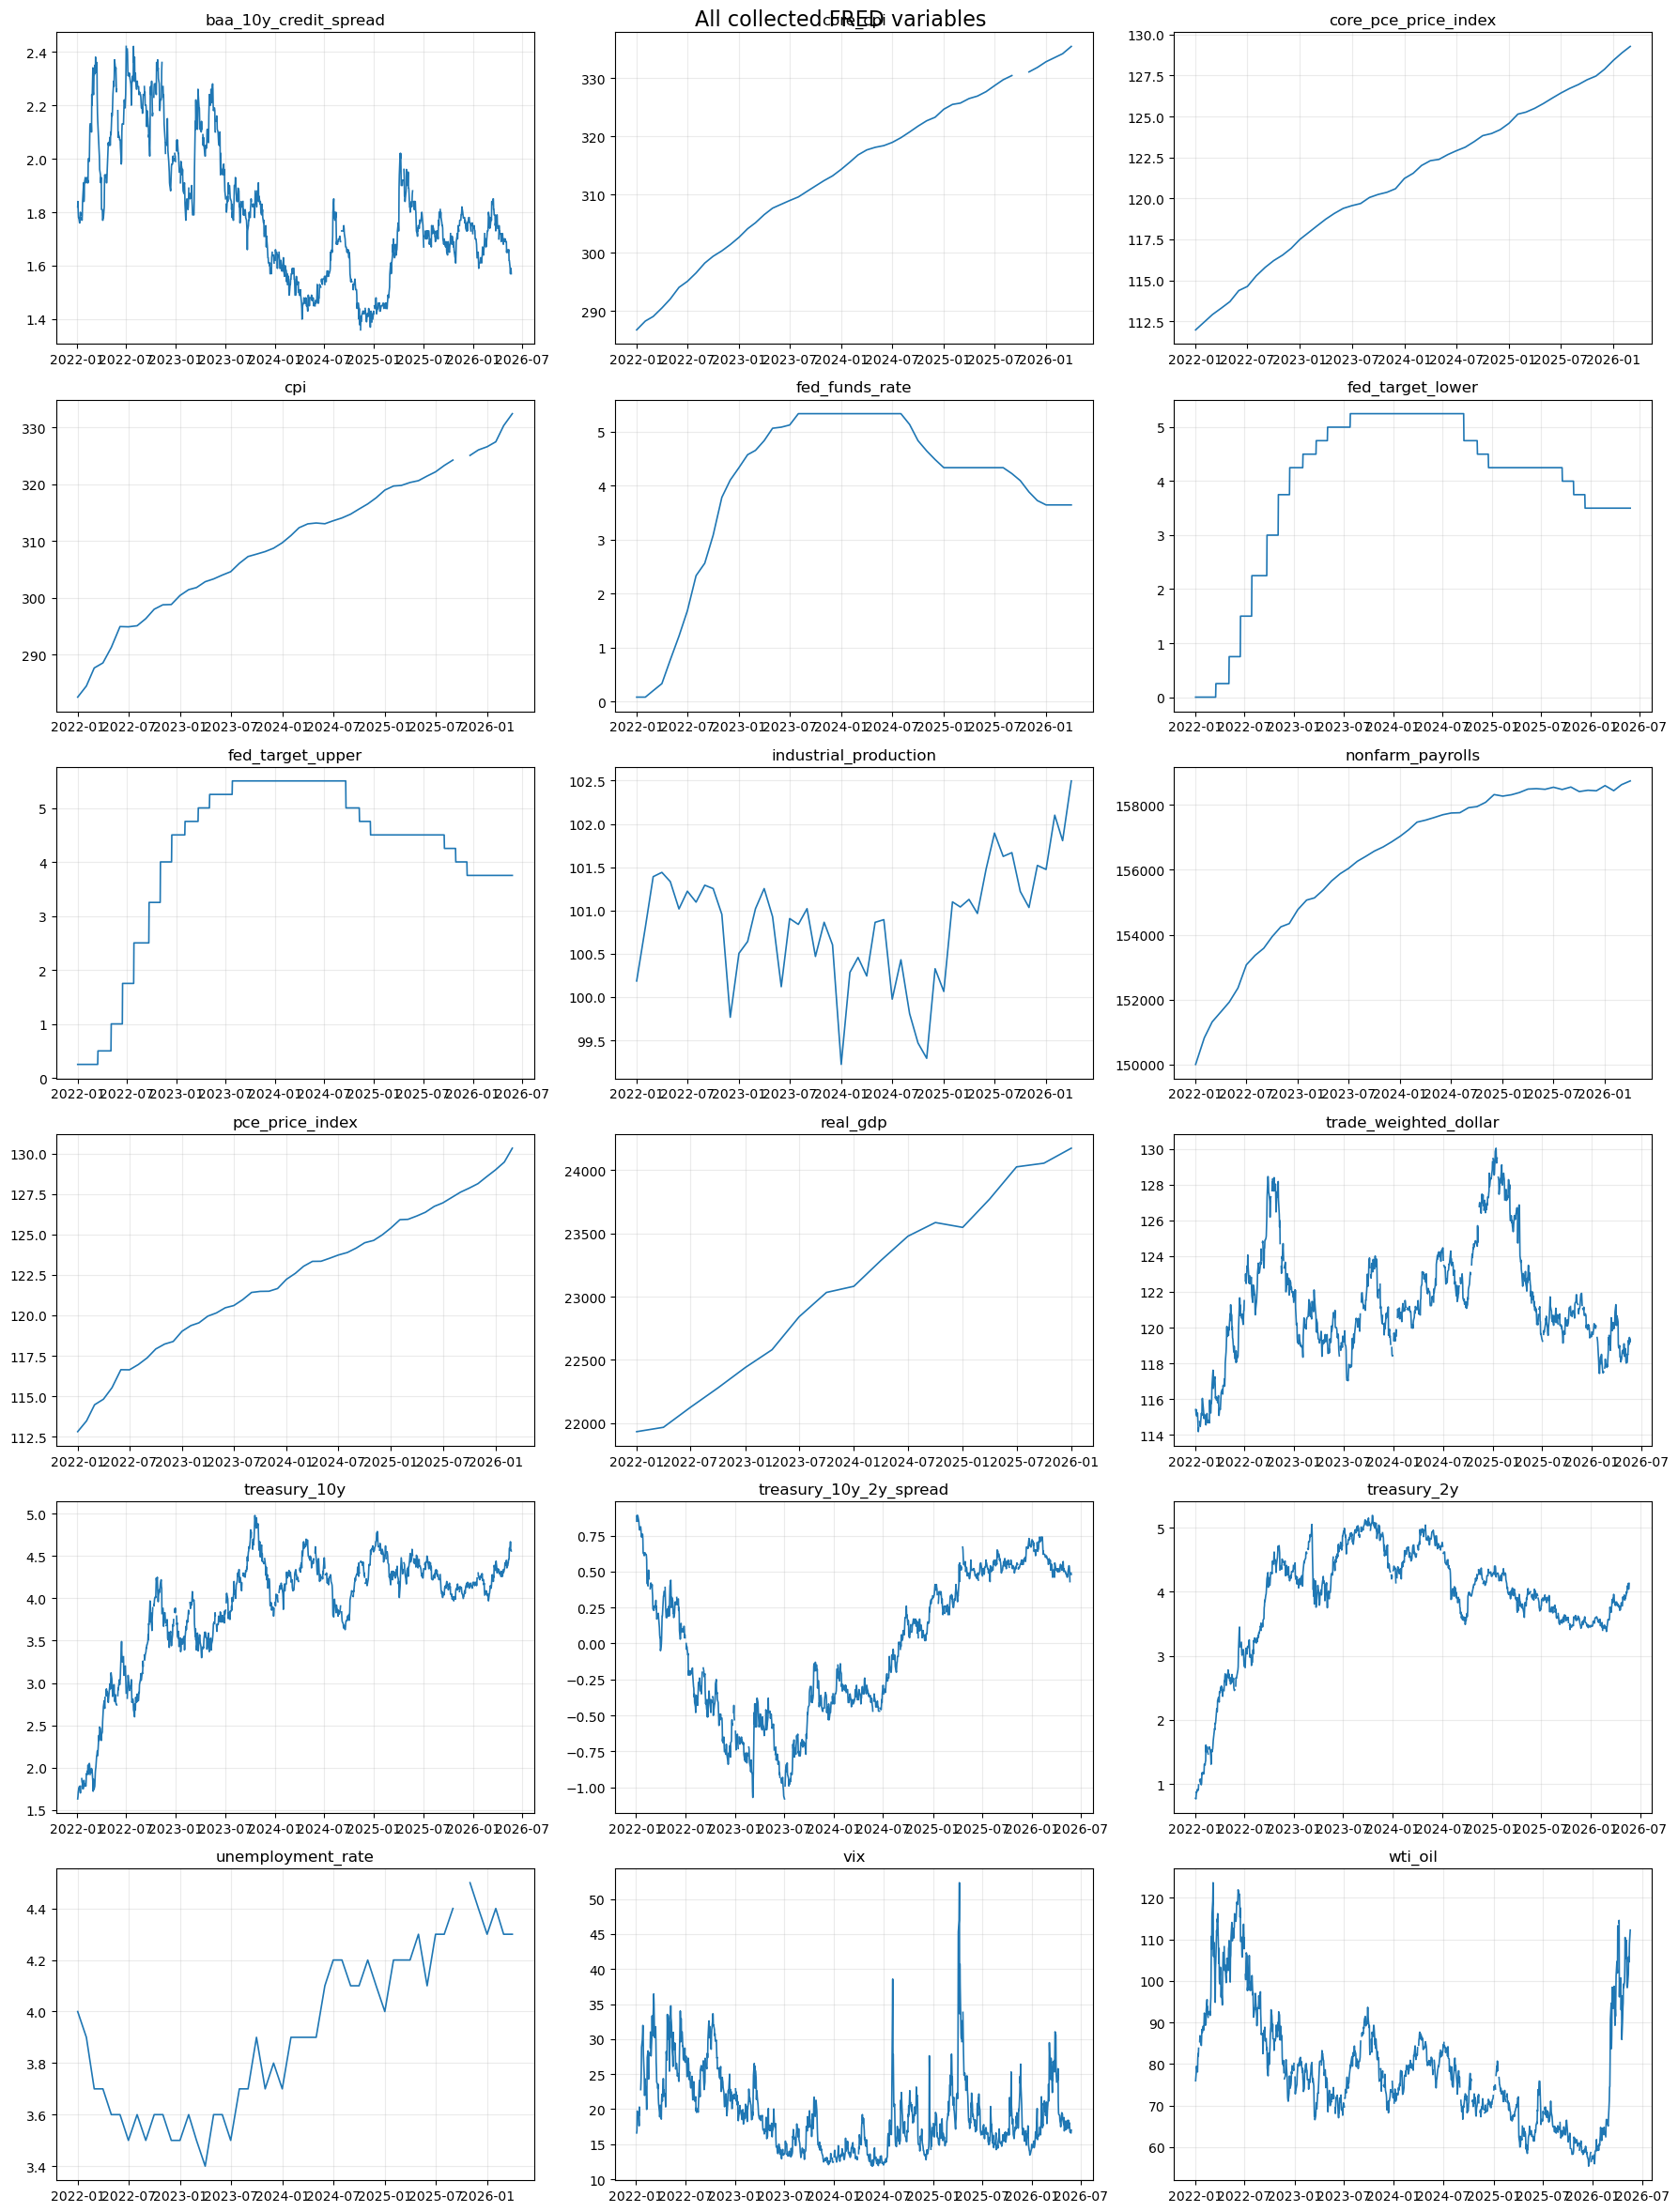

In [10]:
features = sorted(raw["feature"].dropna().unique())
columns = 3
rows = int(np.ceil(len(features) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(18, max(4 * rows, 5)), squeeze=False)
for feature, ax in zip(features, axes.flat):
    subset = raw.loc[raw["feature"] == feature]
    ax.plot(subset["date"], subset["value"], linewidth=1.2)
    ax.set_title(feature)
    ax.grid(alpha=0.25)
for ax in axes.flat[len(features):]:
    ax.set_visible(False)
fig.suptitle("All collected FRED variables", fontsize=16)
plt.tight_layout()
plt.show()

## Leakage warning: observation date is not availability date

FRED's `date` normally identifies the period an observation describes. For
example, a CPI value dated January 1 describes January, but it is published
later. Many FRED values are also revised after their first publication.

This repository does not appear leakage-safe merely because it has a `date`
column. Before using it for forecasting:

1. Determine the first public release date for each observation.
2. Prefer ALFRED vintage data if modelling what was genuinely known historically.
3. Join macro values to prices using `available_from_date`, not just `date`.
4. Otherwise, lag each series conservatively according to its release schedule
   and document that approximation.

In [11]:
availability_columns = [
    c for c in raw.columns
    if any(term in c.lower() for term in ["release", "available", "vintage", "realtime"])
]
print(f"Potential availability/vintage columns found: {availability_columns}")
if not availability_columns:
    print("No explicit public-availability or vintage columns were found in the canonical raw table.")
    print("Treat the current data as revised/latest-vintage macro data, not point-in-time data.")

Potential availability/vintage columns found: []
No explicit public-availability or vintage columns were found in the canonical raw table.
Treat the current data as revised/latest-vintage macro data, not point-in-time data.


## Automated summary

In [12]:
print("FRED MACRO DATASET SUMMARY")
print(f"- Repository revision: {REVISION}")
print(f"- Canonical table: {raw_name}")
print(f"- Rows: {len(raw):,}")
print(f"- Variables: {raw['feature'].nunique()}")
print(f"- Earliest observation date: {raw['date'].min()}")
print(f"- Latest observation date: {raw['date'].max()}")
print(f"- Duplicate feature/date rows: {int(duplicate_mask.sum()):,}")
print()
print("Final stored observation by variable:")
for row in coverage.sort_values("feature").itertuples():
    print(f"  {row.feature}: {row.last_observation_date} ({row.observations:,} rows)")
print()
print("Important: different native frequencies mean different legitimate final dates.")
print("A monthly series ending earlier than a daily series does not necessarily indicate missing collection.")
print("The dataset does not provide point-in-time availability dates unless reported above.")

FRED MACRO DATASET SUMMARY
- Repository revision: 3b12b255a8eabbfbb84d6311169bd91b268ef5c8
- Canonical table: fred_macro_raw.csv
- Rows: 11,669
- Variables: 18
- Earliest observation date: 2022-01-01 00:00:00
- Latest observation date: 2026-05-27 00:00:00
- Duplicate feature/date rows: 0

Final stored observation by variable:
  baa_10y_credit_spread: 2026-05-26 00:00:00 (1,147 rows)
  core_cpi: 2026-04-01 00:00:00 (52 rows)
  core_pce_price_index: 2026-03-01 00:00:00 (51 rows)
  cpi: 2026-04-01 00:00:00 (52 rows)
  fed_funds_rate: 2026-04-01 00:00:00 (52 rows)
  fed_target_lower: 2026-05-27 00:00:00 (1,608 rows)
  fed_target_upper: 2026-05-27 00:00:00 (1,608 rows)
  industrial_production: 2026-04-01 00:00:00 (52 rows)
  nonfarm_payrolls: 2026-04-01 00:00:00 (52 rows)
  pce_price_index: 2026-03-01 00:00:00 (51 rows)
  real_gdp: 2026-01-01 00:00:00 (17 rows)
  trade_weighted_dollar: 2026-05-22 00:00:00 (1,145 rows)
  treasury_10y: 2026-05-26 00:00:00 (1,147 rows)
  treasury_10y_2y_spread